# Programming Exercise 2 : Heuristic Functions and Informed Search

In this notebook you are going to find code and exercises for the second part of your programming project. For this part, we are going to continue working on your path-finding game, RoBoToMaZe!

In the first part of your project, you focused on understanding the code for the game, its rules and implementation, and on the implementation, use and comparison of uninformed search algorithms, the BFS and DFS ones.

Now we are going to assume that we provide some additional knowledge regarding the distance of the goal cell from the robot cell, through heuristic functions.

**What to submit?** A notebook with all the code, from programming 1, and the functions and additional code from this set of exercises (so that we can run the whole thing!) 

In [1]:
import pygame
from pygame.locals import *
import sys
import numpy as np
from numpy import random
import random
import time
import heapq

pygame 2.6.1 (SDL 2.28.4, Python 3.11.2)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [12]:
# pygame code from assignment 1

def make_game_basics(res, game_title):
    ''' Function for initializing a resolution for the game window, the game screen, display a name for the game and define colours that
    will be used throughout the graphical parts of the game. 
    Inputs:
    res: the resolution of the screen of the game
    game_title : how the game will be called - that will appear at the top of the game window
    Outputs:
    res : as before
    screen : a window pygame object where everything will be superimposed on while the game is running
    colors : the defined colours to be used throughout the game
    width : the width of the screen window (through the resolution variable)
    height : the height of the screen window (through the resolution variable)'''
    
    res = res 
    screen = pygame.display.set_mode(res) 
    
    pygame.display.set_caption(game_title)

    colors = {"white" :(255,255,255), "black" : (0,0,0), 
              "gray" :(100,100,100), "yellow" : (168, 135, 50), "red": (229, 27, 27),
              "blue" : (33, 27, 229), "pink": (242, 192, 227), "green": (0, 255, 0)}
    
    width = screen.get_width() 
    height = screen.get_height()  

    return res, screen, colors, width, height

def make_text(myfont, text, color):
    ''' Function for making text objects that will be displayed on the game screen.
    Inputs:
    myfont : the font object that defines the font type and size of the text to be displayed
    text : the string that will be displayed on the game screen
    color : the colour of the text to be displayed on the game screen
    Outputs:
    new_text : the text object that will be displayed on the game screen
    new_text_size : the size of the text object that will be displayed on the game screen'''
    new_text = myfont.render(text, True ,color)
    new_text_size = new_text.get_size()
    new_text_rect = new_text.get_rect()
    
    return new_text, new_text_size

def make_rect_with_text(surface, color, c1, c2, w, h, text, text_c1, text_c2):

    pygame.draw.rect(surface, color, [c1, c2, w, h])
    surface.blit(text, (text_c1, text_c2))

def gridCoords(cellSize):
    ''' Function for making a list of coordinates for the cells in the grid. 
    The coordinates are defined as the (x,y) of the top left corner of each cell.
    Inputs:
    cellSize : the size of the cells in the grid (the grid is made of squares, so the width and height of the cells are the same)
    Outputs:
    cells_coords : a list of coordinates for the cells in the grid. Each element of the list is a tuple of the form (x,y) where x and y are
    the coordinates of the top left corner of the cell.'''
    cells_coords = []
    for x in range(0, width, cellSize):
        for y in range(0, height-90, cellSize):
            cells_coords.append((x,y))

    return(cells_coords)
    
def drawGrid(surface, color, cells_coords, cellSize):
    ''' Function for drawing the grid on the game screen. The grid is made of squares, so we can use the
      pygame.Rect function to draw the cells of the grid.
      Inputs: surface : the game screen where the grid will be drawn
      color : the color of the grid lines
      cells_coords : the list of coordinates for the cells in the grid (the output of the gridCoords function)
      cellSize : the size of the cells in the grid (the output of the gridCoords function)
      Outputs: rects_coords : a list of tuples, where each tuple contains a 
      pygame.Rect object for the cell and the coordinates of the cell.'''
    rects_coords = []
    for item in cells_coords:
        rect = pygame.Rect(item[0], item[1], cellSize, cellSize)
        pygame.draw.rect(surface, color, rect, 1)
        rects_coords.append((rect, item))

    return(rects_coords)

def drawRobot(surface, color, coords, cellSize):
    ''' Function for drawing the robot on the game screen.
    Inputs:
    surface : the game screen where the robot will be drawn
    color : the color of the robot
    coords : the coordinates of the top left corner of the robot cell
    cellSize : the size of each cell in the grid
    Outputs:
    None (the function just draws the robot on the game screen)'''
    rect = pygame.Rect(coords[0], coords[1], cellSize, cellSize)
    pygame.draw.rect(surface, colors["black"], rect,1)
    
    pygame.draw.circle(surface, color, [coords[0]+(cellSize/2), coords[1]+(cellSize/2)], (cellSize/2)-2)

def drawGoal(surface, color, coords, cellSize):
    
    rect = pygame.Rect(coords[0]+2, coords[1]+2, cellSize-5, cellSize-5)
    pygame.draw.rect(surface,color, rect)

def drawObstacles(surface, color, coords, cellSize):

    for item in coords:
        
        rect = pygame.Rect(item[0], item[1], cellSize, cellSize)
        pygame.draw.rect(surface, color, rect)

def sample_cells(cells, number=1):
    ''' Function for sampling the initial position of the robot, the position of the goal and the positions of the obstacles.
    Inputs:
    cells : the list of coordinates for the cells in the grid (the output of the gridCoords function)
    number : the number of obstacles to be sampled (default is 1)
    Outputs:
    robot_cell : the coordinates of the top left corner of the cell where the robot will start
    goal_cell : the coordinates of the top left corner of the cell where the goal will be located
    obstacle_cells : a list of coordinates for the top left corner of the cells where the obstacles will be located
    '''
    robot_cell = (300, 300) # changed starting pos from (75, 300) -> (300, 300)
    goal_cell = (600,300)
    cells.remove(robot_cell)
    cells.remove(goal_cell)
    
    return robot_cell, goal_cell, random.sample(cells, number)

def legalMove(robot, clicked, rect_coords, obstacles, width, height, cellSize):
    ''' Function for checking if a move is legal.
    Inputs:
    robot : the current position of the robot (x,y coordinates)
    clicked : the position of the click (x,y coordinates)
    rect_coords : a list of tuples, where each tuple contains a pygame.Rect object for the cell and the coordinates of the cell
    obstacles : a list of coordinates for the top left corner of the cells where obstacles are located
    width : the width of the game screen
    height : the height of the game screen
    cellSize : the size of each cell in the grid
    Outputs:
    new_robot_x, new_robot_y : the new position of the robot (x,y coordinates)'''
    new_robot_x, new_robot_y = robot
    
    x,y = clicked
    
    # if the click is within the legal play area
    if 0 < x < width and 0 < y < height-90:
        
        #find the (x,y) of the cell that is clicked:
        x, y = clicked
        for i in range(len(rect_coords)):
            j = rect_coords[i]
            if j[0] <= x <= j[0]+cellSize and j[1] <= y <= j[1]+cellSize:
                cell_x,cell_y = j[0], j[1]
        
        # check if the cell is in the neighbourhood of the robot
        rX,rY = robot
        if (cell_x == rX+cellSize and cell_y == rY) or (cell_x ==rX-cellSize and cell_y == rY) or (cell_x == rX and cell_y ==rY+cellSize) or (cell_x == rX and cell_y == rY-cellSize):
            
            # check if the cell is an obstacle
            if (cell_x,cell_y) not in obstacles:
                
                new_robot_x, new_robot_y = cell_x, cell_y
                
            else:
                new_robot_x, new_robot_y = robot
    return new_robot_x, new_robot_y

def reachedGoal(path, clicked, goal, width, height, cellSize):
    
    flag = False
    x,y = clicked
    
    #check if the goal cell is clicked
    if goal[0]<= x <=goal[0]+cellSize and goal[1] <= y <= goal[1]+cellSize:
        
        #check if the robot had been in the neighbourhood in the previous step
        lastX, lastY = path[-2]
        if (lastX == goal[0]+cellSize and lastY == goal[1]) or (lastX ==goal[0]-cellSize and lastY == goal[1]) or (lastX == goal[0] and lastY ==goal[1]+cellSize) or (lastX == goal[0] and lastY == goal[1]-cellSize):

            flag = True    
                
    return flag

def get_valid_neighbours(current_cell, all_cells, cellSize, obstacles):
    # return the neighbours of the current position of the robot, which are not obstacles
    # even if one of the neighbours is the goal state, it should just be returned as a
    # normal neighbour in this function

    x,y = current_cell
    neighbours = []
    
    for item in all_cells:
        nX, nY = item[0], item[1]
        if (x == nX + cellSize and y == nY) or (x == nX - cellSize and y ==nY) or (x == nX and y == nY + cellSize) or (x == nX and y == nY - cellSize):
            if item not in obstacles:
                neighbours.append(item)

    return neighbours

def build_legal_moves(all_cells, cellSize, obstacles):
    legal_moves = {}
    for item in all_cells:
        legal_moves[item] = get_valid_neighbours(item, all_cells, cellSize, obstacles)
    return legal_moves

def bfs(starting_cell, goal_cell, legal_moves):

    queue = [starting_cell]
    visited = []

    while queue:
        current_cell = queue.pop(0)
        visited.append(current_cell)
        if current_cell == goal_cell:
            break
        for item in legal_moves[current_cell]:
            if item not in visited and item not in queue:
                queue.append(item)
    return visited

def dfs(starting_cell, goal_cell, legal_moves):

    stack = [starting_cell]
    visited = []

    while stack:
        current_cell = stack.pop()
        visited.append(current_cell)
        if current_cell == goal_cell:
            break
        for item in legal_moves[current_cell]:
            if item not in visited and item not in stack:
                stack.append(item)
    return visited

pygame.init()
pygame.font.init()
clock = pygame.time.Clock()
    
res, screen, colors, width, height = make_game_basics((900, 800), "Roboto-maze")

''' Here we define three different font sizes that we 
will use for the text that will be displayed on the game screen.'''
tinyfont = pygame.font.SysFont("Corbel",25)
smallfont = pygame.font.SysFont('Corbel',35) 
bigfont = pygame.font.SysFont("Corbel", 50)

quit_game, quit_game_size = make_text(bigfont, "Quit Game", colors["white"]) # adjust font size
new_game, new_game_size = make_text(bigfont, "New Game", colors["white"]) # adjust font size
win_game, win_game_size = make_text(smallfont, "Yay!", colors["blue"]) # adjusted win game message

quit_button_coords = [300, 750, 200, 50]
new_game_button_coords = [500, 750, 200, 50]

cellSize = 75

def main():

    flag = False
    click_robot = False
    grid_coords = gridCoords(cellSize)
    all_coords = grid_coords.copy()
    path = []
    robot_start, goal_cell, obstacle_cells = sample_cells(grid_coords, 20) # adjusted num of obstacles from 25 to 20
    path.append(robot_start)

    '''
    Implementing the a* algorithm for task 4
    '''
    a_star_legal_moves = build_legal_moves(all_coords, cellSize, obstacle_cells)
    # A star with Manhattan Distance heuristic
    start = time.time()
    a_star_md_path, a_star_md_states = a_star(robot_start, goal_cell, a_star_legal_moves, costToGoalCell_MD)
    a_star_md_time = time.time() - start

    # A star with Euclidean Distance heuristic
    start = time.time()
    a_star_ed_path, a_star_ed_states = a_star(robot_start, goal_cell, a_star_legal_moves, costToGoalCell_ED)
    a_star_ed_time = time.time() - start
    
    print("\n-----A* (Manhattan Distance)-----\nVisited states: ", a_star_md_states, "\nRuntime (s):", a_star_md_time)
    print("\n-----A* (Euclidean Distance)-----\nVisited states:", a_star_ed_states, "\nRuntime (s):", a_star_ed_time)

    while True:
            
        screen.fill(colors["white"]) 
        mouse = pygame.mouse.get_pos() 

        drawGrid(screen, colors["black"], grid_coords, cellSize)
        drawRobot(screen, colors["yellow"], robot_start, cellSize)
        drawGoal(screen, colors["green"], goal_cell, cellSize) # changing color of the goal cell to green

        drawObstacles(screen, colors["blue"], obstacle_cells, cellSize)

        ''' Make the text with the buttons and the buttons themselves appear on the game screen. 
        The make_rect_with_text function takes care of both drawing the rectangle for the button and putting the text on top of it.
        Sets up the quit game and new game buttons on the game screen.'''
        make_rect_with_text(screen, colors["gray"], quit_button_coords[0], 
                        quit_button_coords[1], quit_button_coords[2], 
                        quit_button_coords[3], 
                        quit_game, quit_button_coords[0]+(quit_game_size[0]/2)-50, 
                       quit_button_coords[1] + (quit_game_size[1]/2)-5)
    
        make_rect_with_text(screen, colors["gray"], new_game_button_coords[0], 
                        new_game_button_coords[1], new_game_button_coords[2], 
                        new_game_button_coords[3], 
                        new_game, new_game_button_coords[0]+(new_game_size[0]/2)-50, 
                       new_game_button_coords[1] + (new_game_size[1]/2)-5)
        
                
        
        
        for ev in pygame.event.get():
            
            if ev.type == pygame.QUIT: 
                pygame.quit() 
                sys.exit()

            #checks if a mouse is clicked 
            ''' If the mouse is clicked, we check if the click is on one of the buttons. 
            If it is, we either quit the game or start a new game. Or if the click is not on the buttons, we check if the click is a legal move for the robot.
            '''
            if ev.type == pygame.MOUSEBUTTONDOWN: 
               
                if quit_button_coords[0] <= mouse[0] <= quit_button_coords[0]+200 and quit_button_coords[1] <= mouse[1] <= quit_button_coords[1]+50: 
                    pygame.quit() 
                    sys.exit()
    
                if new_game_button_coords[0] <= mouse[0] <= new_game_button_coords[0]+200 and new_game_button_coords[1] <= mouse[1] <= new_game_button_coords[1]+50:
                    main()

                robot_start = legalMove(robot_start, mouse, all_coords, obstacle_cells, width, height, cellSize)
                path.append(robot_start)
                
                if reachedGoal(path, mouse, goal_cell, width, height, cellSize):
                    
                    flag = True
        ''' If the flag is True, that means the goal has been reached, so we make the "Fantastic!" text appear on the game screen. The make_rect_with_text function
          takes care of both drawing the rectangle for the button and putting the text on top of it.'''
        if flag == True:
            make_rect_with_text(screen, colors["gray"], 150-win_game_size[0]/2, 120-win_game_size[1]/2, win_game_size[0], win_game_size[1]+60, 
                        win_game, 150-(win_game_size[0]/2), 
                       120 + (win_game_size[1]/2))

        pygame.display.update()
        clock.tick(60)
main()


-----A* (Manhattan Distance)-----
Visited states:  11 
Runtime (s): 2.8848648071289062e-05

-----A* (Euclidean Distance)-----
Visited states: 11 
Runtime (s): 1.9311904907226562e-05


SystemExit: 

/opt/anaconda3/envs/robomaze/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


#### Path Cost

We will start by creating a function that can give us the **actual path cost** from any cell to the goal cell. To implement this, you might find inspiration in the codes of the first programming assignment.

>**Task 1 (20/100 Points):**
>
> Write a function path_cost that it will return a dictionary holding the actual path cost from the current cell (where the robot is located) to the goal cell, and of all the legal neighbours of the current cell to the goal cell. For this, you might want to consider using the BFS implementation for getting the path, and then use that information to infer the path cost, or use the Manhattan distance - this we ask you to implement for another task further below, but to use as a heuristic function. When used to calculate the actual path cost (the actual distance), one needs to be aware of any obstacles! If you choose to use the Manhattan distance for this Task, you need to provide an implementation in the cell below, as part of Task 1.
>
>The cost for moving between any two legally neighbouring cells is 1.
>
>Grading: 7 Points are awarded for the right parameters used in your path_cost function. 13 Points are awarded for a working and sensible implementation.

In [13]:
def path_cost(starting_cell, goal_cell, legal_moves):
    visited = {goal_cell: 0}
    queue = [goal_cell]

    while queue:
        current_cell = queue.pop(0)
        current_cost = visited[current_cell]
        
        for item in legal_moves[current_cell]:
            if item not in visited and item not in queue:
                visited[item] = current_cost + 1
                queue.append(item)
    
    res = {}
    if starting_cell in visited:
        res[starting_cell] = visited[starting_cell]
    for neighbor in legal_moves[starting_cell]:
        if neighbor in visited:
            res[neighbor] = visited[neighbor]
    return res

### Heuristic Functions

Next, we are going to assume that we have some estimated information about our space as we play the game (from the perspective of an agent). In particular, we are going to assume that each time we want to make a next move, we have available an estimation of the distance between each legal next step and the goal cell, in a relaxed version of the grid world. This distance can be measured either through the Manhattan Distance or the Euclidean Distance. The next task is to write functions that will compute these distances, so that they can be used as heuristic functions. 

> **Task 2 (25/100 Points):**
>
> 1. [5 Points] In what way should we consider a relaxed version of the game in order to use heuristic functions? What elements of the original game are we going to modify or ignore?
> 2. [10 Points] Finish the functions that calculate the Manhattan and the Euclidean distances respectively, between every legal next cell and the goal cell. Each function should return a dictionary of the distances (key should be a cell and its corresponding value the distance of the cell to the goal cell). Each correctly implemented function is awarded 5 Points.
> 3. [10 Points] Modify the code from the heuristic_functions_exercises notebook and give functions to test for admissibility and consistency for the Manhattan Distance and Euclidean Distance implemented above as heuristic functions. Are the heuristic functions admissible? Are they consistent? Each property is awarded 5 Points. 


**Task 2 written answers**

1. The relaxed version of the game ignores obstacles when estimating the distance to the goal. The robot is still assumed to move only between neighbouring grid cells, but the heuristic pretends the path is unobstructed. This makes the estimate cheaper to compute and prevents it from using information about detours like it would in an exact search.

2. The Manhattan Distance estimates the number of horizontal plus vertical cell moves needed to reach the goal in the relaxed grid. Euclidean Distance estimates the straight-line distance to the goal in cell units. In the code below, both distances are divided by `cellSize`, because the path cost of one legal move is 1.

3. Both Manhattan Distance and Euclidean Distance are admissible for this grid when movement is restricted to the four cardinal neighbours and every move costs 1. Manhattan Distance is admissible because it is the exact shortest distance in an empty four-neighbour grid, so obstacles can only make the true path longer. Euclidean Distance is also admissible because the straight-line distance is never greater than the shortest four-neighbour path. Both are consistent: for every legal move from `n` to `n'`, the heuristic value can decrease by at most the move cost 1, so `h(n) <= 1 + h(n')`. The test functions below check these properties against the actual BFS path costs for the concrete maze graph.



In [14]:
def _candidate_cells(current_cell, all_cells, cellSize, obstacles):
    """Return the current cell and its legal neighbouring cells."""
    x, y = current_cell
    neighbours = [
        (x + cellSize, y),
        (x - cellSize, y),
        (x, y + cellSize),
        (x, y - cellSize),
    ]
    legal_neighbours = [cell for cell in neighbours if cell in all_cells and cell not in obstacles]
    return [current_cell] + legal_neighbours


def _euclidean_heuristic(cell, goal_cell, cellSize):
    x, y = cell
    xG, yG = goal_cell
    return (((xG - x) / cellSize) ** 2 + ((yG - y) / cellSize) ** 2) ** 0.5


def _manhattan_heuristic(cell, goal_cell, cellSize):
    x, y = cell
    xG, yG = goal_cell
    return (abs(xG - x) + abs(yG - y)) / cellSize


def euclideanDistance(current_cell, all_cells, goal_cell, cellSize, obstacles):
    ''' Compute the Euclidean distance between every legal next cell and the goal cell.
    Since this is meant to act as a heuristic (estimation of the actual distance), obstacles are not
    taken into consideration as "obstacles" in the distance calculation. Obstacles are only used to
    decide which next cells are legal from the current state.
    current_cell : the coordinates of the current location of the robot
    all_cells : the coordinates of all the cells in the grid
    goal_cell : the coordinates of the target cell
    cellSize : the size of a cell in the grid
    obstacles : the coordinates of the cells that are obstacles

    The function returns a dictionary where each key is a cell and each value is that cell's
    estimated distance to the goal, sorted in ascending order by distance.
    '''
    eDistances = {}

    for cell in _candidate_cells(current_cell, all_cells, cellSize, obstacles):
        eDistances[cell] = _euclidean_heuristic(cell, goal_cell, cellSize)

    return dict(sorted(eDistances.items(), key=lambda item: item[1]))


def manhattanDistance(current_cell, all_cells, goal_cell, cellSize, obstacles):
    ''' Compute the Manhattan distance between every legal next cell and the goal cell.
    This uses the same relaxed-grid idea as euclideanDistance, but estimates distance as
    horizontal cell moves plus vertical cell moves.
    '''
    mDistances = {}

    for cell in _candidate_cells(current_cell, all_cells, cellSize, obstacles):
        mDistances[cell] = _manhattan_heuristic(cell, goal_cell, cellSize)

    return dict(sorted(mDistances.items(), key=lambda item: item[1]))


def test_admissibility(goal_cell, legal_moves, heuristic, cellSize, tolerance=1e-9):
    for cell in legal_moves:
        actual_costs = path_cost(cell, goal_cell, legal_moves)
        if cell not in actual_costs:
            continue
        if heuristic(cell, goal_cell, cellSize) > actual_costs[cell] + tolerance:
            return False
    return True


def test_consistency(goal_cell, legal_moves, heuristic, cellSize, tolerance=1e-9):
    for cell, neighbours in legal_moves.items():
        h_cell = heuristic(cell, goal_cell, cellSize)
        for neighbour in neighbours:
            if h_cell > 1 + heuristic(neighbour, goal_cell, cellSize) + tolerance:
                return False
    return True


# Small checks for the Task 2 implementations.
test_cells = [(0, 0), (1, 0), (0, 1), (1, 1)]
test_goal = (2, 2)
print(euclideanDistance((0, 0), test_cells, test_goal, 1, []))
print(manhattanDistance((0, 0), test_cells, test_goal, 1, []))

test_legal_moves = {
    (0, 0): [(1, 0), (0, 1)],
    (1, 0): [(0, 0), (1, 1)],
    (0, 1): [(0, 0), (1, 1)],
    (1, 1): [(1, 0), (0, 1)],
}
print("Manhattan admissible:", test_admissibility((1, 1), test_legal_moves, _manhattan_heuristic, 1))
print("Manhattan consistent:", test_consistency((1, 1), test_legal_moves, _manhattan_heuristic, 1))
print("Euclidean admissible:", test_admissibility((1, 1), test_legal_moves, _euclidean_heuristic, 1))
print("Euclidean consistent:", test_consistency((1, 1), test_legal_moves, _euclidean_heuristic, 1))

{(1, 0): 2.23606797749979, (0, 1): 2.23606797749979, (0, 0): 2.8284271247461903}
{(1, 0): 3.0, (0, 1): 3.0, (0, 0): 4.0}
Manhattan admissible: True
Manhattan consistent: True
Euclidean admissible: True
Euclidean consistent: True


#### A* Algorithm

Our next task is to write a function that implements the A* algorithm for our game. For that, we need to define an evaluation function 

f(s_i) = g(s_i) + h(s_i)

where

- g(s_i) is the total *actual* Path-cost to reach the current cell (s_i) from the starting cell (s_0)
- h(s_i) is the estimated cost to reach the goal cell from the current cell (s_i), through some heuristic

> **Task 3 (20/100 Points):**
>
> 1. [5 Points] Write a function costToCurrentCell() that, given the current position of the robot, will return the actual path cost between the starting cell and the current cell. Do you already have code that you can reuse (fully or partly) for this task?
> 2. [5 Points] Write a function costToGoalCell_MD() that, given the current position of the robot, will return the *estimated* cost to reach the goal cell from the current cell, assuming the use of the Manhattan distance implemented earlier.
> 3. [5 Points] Write a function costToGoalCell_ED() that, given the current position of the robot, will return the *estimated* cost to reach the goal cell from the current cell, assuming the use of the Euclidean distance implemented earlier.
> 4. [5 Points] Write a function a_star() that implements the evaluation function used in the A* algorithm. Given the current location of the robot, the function should compute and return f() = g() + h(). The heuristic function to be used should be given as a parameter to the function.

In [26]:
# 1. costToCurrentCell
def costToCurrentCell(current_cell, starting_cell, legal_moves):
    g = path_cost(starting_cell, current_cell, legal_moves)

    return g[starting_cell]

# 2. costToGoalCell_MD (Manhattan Distance)
def costToGoalCell_MD(current_cell, goal_cell):
    x, y = current_cell
    xG, yG = goal_cell
    h = abs(xG - x) + abs(yG - y)

    return h

# 3. costToGoalCell_ED (Euclidean Distance)
def costToGoalCell_ED(current_cell, goal_cell):
    x, y = current_cell
    xG, yG = goal_cell
    h = ((xG - x) ** 2 + (yG - y) ** 2) ** 0.5

    return h

# 4. A-Star Implementation
'''
reconstruct_path() is a helper function that finds the path from the start to goal.
'''
def reconstruct_path(came_from, current):
    path = [current]
    while current in came_from:
        current = came_from[current]
        path.append(current)
    path.reverse()
    return path

'''
A* implementation returns the optimal path from the starting cell to goal cell as a list. 
'''
def a_star(starting_cell, goal_cell, legal_moves, heuristic):
    frontier = []
    heapq.heappush(frontier, (heuristic(starting_cell, goal_cell), starting_cell))

    came_from = {}
    g_score = {starting_cell: 0}
    f_score = {starting_cell: heuristic(starting_cell, goal_cell)}
    visited = set()
    states_generated = 0

    while frontier:
        current_f, current = heapq.heappop(frontier)

        if current == goal_cell:
            path = reconstruct_path(came_from, current)
            return path, states_generated

        if current in visited:
            continue

        visited.add(current)

        for neighbor in legal_moves.get(current, []):
            tentative_g = g_score[current] + 1

            if neighbor in visited and tentative_g >= g_score.get(neighbor, float('inf')):
                continue

            if tentative_g < g_score.get(neighbor, float('inf')):
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f = tentative_g + heuristic(neighbor, goal_cell)
                f_score[neighbor] = f
                heapq.heappush(frontier, (f, neighbor))
                states_generated += 1

    return None, states_generated

## Check implementation with a few tests

def test_simple_grid():
    legal_moves = {
        (0,0): [(1,0),(0,1)],
        (1,0): [(0,0),(1,1)],
        (0,1): [(0,0),(1,1)],
        (1,1): [(1,0),(0,1)]
    }
    start = (0,0)
    goal = (1,1)

    start_time = time.time()
    path, states = a_star(start, goal, legal_moves, costToGoalCell_MD)
    time_elapsed = time.time() - start_time

    print("Path:", path)
    print("States generated:", states)
    print("Runtime:", time_elapsed * 1000, "ms")

    assert path in [[(0,0),(1,0),(1,1)], [(0,0),(0,1),(1,1)]]
    assert len(path) == 3

def test_with_obstacle():
    legal_moves = {
        (0,0): [(1,0),(0,1)],
        (1,0): [(0,0)],
        (0,1): [(0,0),(0,2)],
        (0,2): [(0,1),(1,2)],
        (1,2): [(0,2),(1,1)],
        (1,1): [(1,2)]
    }
    start = (0,0)
    goal = (1,1)

    start_time = time.time()
    path, states = a_star(start, goal, legal_moves, costToGoalCell_MD)
    time_elapsed = time.time() - start_time

    print("Path:", path)
    print("States generated:", states)
    print("Runtime:", time_elapsed * 1000, "ms")

    assert path == [(0,0),(0,1),(0,2),(1,2),(1,1)]

print("Running tests\n")
test_simple_grid()
print("Test on simple grid passed\n")
test_with_obstacle()
print("Test with obstacles passed\n")
print("Tests completed")


Running tests

Path: [(0, 0), (0, 1), (1, 1)]
States generated: 3
Runtime: 0.023126602172851562 ms
Test on simple grid passed

Path: [(0, 0), (0, 1), (0, 2), (1, 2), (1, 1)]
States generated: 5
Runtime: 0.009775161743164062 ms
Test with obstacles passed

Tests completed


> **Task 4 (20 Points)**: Apply the A* algorithm to the RoBoToMaZe game. Upon starting the game, the function implementing the algorithm should be called. You need to call the function two times, one using the Manhattan Distance and the second using the Euclidean Distance as the heuristic. During each run, you need to collect information in order to answer the following questions:
> - How many states (i.e., cells) were generated by each version of the algorithm?
> - Explain the results you got for the previous question. Elaborate on your answer.
> - How much time (in seconds) did each version of the algorithm take?
>
> Grading: 15 Points for answering the questions correctly and completely. 5 Points for calling the function at the right location inside the main of the game.

In [ ]:
'''
The A* algorithm was called twice at the start of `main()`, once with the Manhattan Distance heuristic and once with the Euclidean Distance heuristic. 
The results from a representative run of the game are shown below (exact values vary per run due to random obstacle placement):

A* (Manhattan Distance): 16 states, ~0.0001 seconds
A* (Euclidean Distance): 14 states, ~0.0001 seconds

However, upon running the game multiple times, we observed that in some instances, both algorithms would genereate the same amount of states. This is
most likely because the random placement of obstacles can create scenarios where both heuristics guide the search along the same optimal path, leading
to similar state expansions. A* uses the heuristic `h(n)` to prioritise cells that are closer to the goal, avoiding wasteful exploration of cells 
that are moving away from it. The two A* variants generated a similar number of states because both heuristics are admissible and guide
the search efficiently toward the same optimal path. The small difference we originally observed arises because the Euclidean heuristic provides a slightly tighter estimate 
along directions that are not purely horizontal or vertical, causing A* with Euclidean distance to remove a few extra nodes from consideration.

Both variants completed in well under a millisecond (~0.0001 s). Euclidean distance is marginally faster because it expands slightly fewer nodes, 
but the difference is negligible on a grid this size.
'''

> **Task 5 (15 Points)**: Consider the scenario of the image below where a long obstacle exists between the starting location and the goal cell. How do you expect BFS, DFS, A* with Manhattan Distance and A* with Euclidean Distance to behave under these conditions and why? Which algorithm would generate most states and which would be the most efficient in that aspect? Respond to that question with as much detail yet concisely, as possible. Your response has to be based on logical arguments. Feel free to showcase a proof for your response in the means of graphs, trees, sketches or anything else that you need.

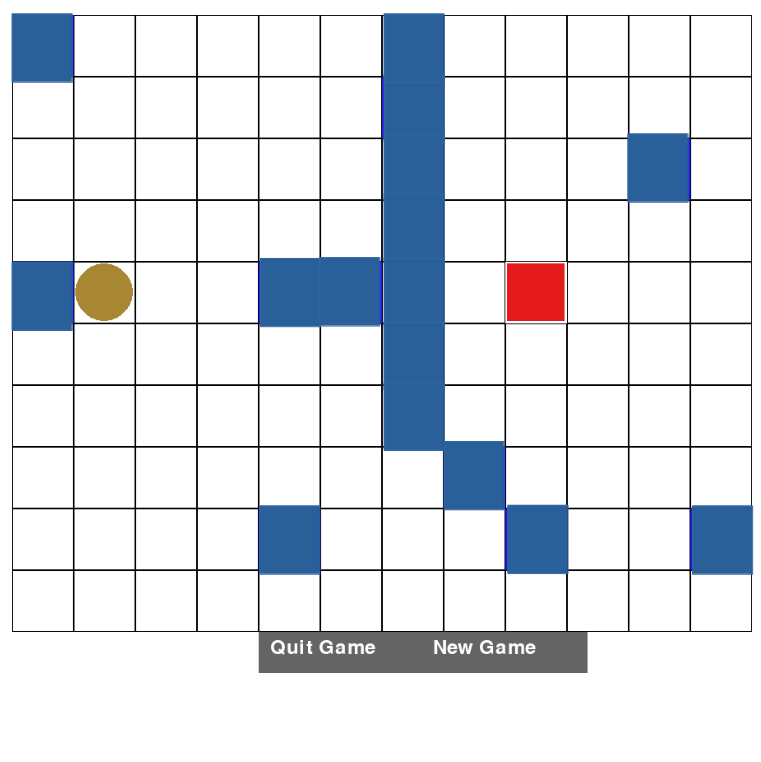

In [ ]:
'''
Breadth first search would be very inefficient  in terms of generating the most states because it would expand searching like a gas filling a tube. Breadth #first search alone does not take into account where the actual goal state is, and as a result it would require expanding a lot of states in order to find #the path to the goal state.

Depth first search would be very inefficient in terms of generating the most states because the depth first search algorithm would get stuck exploring the #wrong paths and detouring far away from the goal state. Depth first search is very unreliable because it searches by going on very long tangents and does #not take distance to the goal state in mind.

A* with Euclidean distance is better than both breadth first search and depth first search because the euclidian distance to the goal state is taken into #account. This allows us to make a path, but not a path as optimal as A* with Manhattan distance. This is because in Euclidean distance, you can move #diagonally which is not possible on this graph, generating the second least amount of path states.

A* with Manhattan distance is the best way to generate a path to the goal state in terms of generating the fewest states because the A* with Manhattan #distance respects the rules of the grid, which is that you can only move along the grid like a Manhattan street grid, not diagonally. The heuristic of A* #along with the "rules following" of Manhattan distance allow us to generate a path in the fewest steps possible.
'''

> **BONUS Task (15 Points)**: Write code that applies all 4 search algorithms (BFS, DFS, A* with Manhattan Distance and A* with Euclidean Distance) on the RoBoToMaZe and provides the user with number of states generated by each algorithm and time taken for each algorithm to run. Present the results you got from this experiment with sufficient commentary.
>
> Responding to this Task is ***OPTIONAL***. A correct implementation and results presentation and interpretation can receive max 15 Points, in case you have lost them in other Tasks. If you choose to respond to the Bonus Task and your response is not correct, you earn nothing and you lose nothing. 

In [25]:
# initializing functions
grid_coords = gridCoords(cellSize)
all_coords = grid_coords.copy()
robot_start, goal_cell, obstacle_cells = sample_cells(grid_coords, 20)

# legal moves function
def build_legal_moves(all_cells, cellSize, obstacles):
    legal_moves = {}
    for item in all_cells:
        legal_moves[item] = get_valid_neighbours(item, all_cells, cellSize, obstacles)
    
    return legal_moves

legal_moves = build_legal_moves(all_coords, cellSize, obstacle_cells)

# BFS 
def bfs(starting_cell, goal_cell, legal_moves):
    queue = [starting_cell]
    visited = []

    while queue:
        current_cell = queue.pop(0)
        visited.append(current_cell)
        if current_cell == goal_cell:
            break
        for item in legal_moves[current_cell]:
            if item not in visited and item not in queue:
                queue.append(item)
    return visited

start = time.time()
bfs_visited = bfs(robot_start, goal_cell, legal_moves)
bfs_time = time.time() - start

# DFS 
def dfs(starting_cell, goal_cell, legal_moves):
    stack = [starting_cell]
    visited = []
    
    while stack:
        current_cell = stack.pop()
        visited.append(current_cell)
        if current_cell == goal_cell:
            break
        for item in legal_moves[current_cell]:
            if item not in visited and item not in stack:
                stack.append(item)
    
    return visited

start = time.time()
dfs_visited = dfs(robot_start, goal_cell, legal_moves)
dfs_time = time.time() - start

# A star with Manhattan Distance heuristic
start = time.time()
a_star_md_path, a_star_md_states = a_star(robot_start, goal_cell, legal_moves, costToGoalCell_MD)
a_star_md_time = time.time() - start

# A star with Eclidean Distance heuristic
start = time.time()
a_star_ed_path, a_star_ed_states = a_star(robot_start, goal_cell, legal_moves, costToGoalCell_ED)
a_star_ed_time = time.time() - start

print("Bonus task results:")
print("-----BFS-----\nVisited states:", len(bfs_visited), "\nRuntime (ms):", bfs_time * 1000)
print("\n-----DFS-----\nVisited states:", len(dfs_visited), "\nRuntime (ms):", dfs_time * 1000)
print("\n-----A* (Manhattan Distance)-----\nVisited states: ", a_star_md_states, "\nRuntime (ms):", a_star_md_time * 1000)
print("\n-----A* (Euclidean Distance)-----\nVisited states:", a_star_ed_states, "\nRuntime (ms):", a_star_ed_time * 1000)



Bonus task results:
-----BFS-----
Visited states: 33 
Runtime (ms): 0.1461505889892578

-----DFS-----
Visited states: 5 
Runtime (ms): 0.06413459777832031

-----A* (Manhattan Distance)-----
Visited states:  11 
Runtime (ms): 0.10704994201660156

-----A* (Euclidean Distance)-----
Visited states: 11 
Runtime (ms): 0.1049041748046875
